In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('./')
sys.path.append('/Users/ASUS/Documents/GitHub/retrospective_t2e_analysis/retrospective_t2e/')

from gls import datasets

import pandas as pd
import numpy as np

def load_aimhigh_trial_data():

  feature_list = {
    # demographic data
    'patient.sas7bdat' : ['Age', 'Sex', 'ethn', 'Race', 'HxDiab', 'Smoke', 'MetabSyn', 'BMI', 'SysBP', 'DiasBP', 
                        'LDL_C_Base', 'HDL_C_Base', 'Trig_Base', 'Glucose_Base', 'Lpa', 'RandAssi']
  }
  outcomes, features = datasets._load_generic_biolincc_dataset('patient.sas7bdat', 
                                                                   'ETPrimaryA6', 'VSDthA6',
                                                                   features=feature_list, 
                                                                   id_col='PatientKey',
                                                                   location='datasets/AIMHIGH/')

  # Convert Censoring Indicator to Binary
  # ie. 1 = Event, 0 = Censored
  outcomes.event = outcomes.event == 1.0 
  
  NaNindex = pd.isna(outcomes.time)
  outcomes = outcomes.loc[~NaNindex]
  features = features.loc[~NaNindex]

  return outcomes, features

In [3]:
import pandas as pd
import torch
from tqdm import tqdm
from examples.cmhe_demo_utils import * 

c:\Users\ASUS\anaconda3\envs\Pandas\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Load the synthetic dataset
outcomes, x = load_aimhigh_trial_data()

# Let's take a look at take the dataset
x.head(5)

(4273, 16)


,Age,DiasBP,Glucose_Base,Lpa,ethn,Sex,HDL_C_Base,SysBP,BMI,HxDiab,RandAssi,Smoke,LDL_C_Base,MetabSyn,Trig_Base,Race
PatientKey,,,,,,,,,,,,,,,,
1.0,69.0,62.0,111.0,17.4,1.0,1.0,33.0,143.0,36.3,1.0,0.0,4.0,75.0,1.0,140.0,5.0
2.0,69.0,72.0,102.0,50.5,1.0,1.0,38.0,116.0,30.9,0.0,0.0,1.0,70.0,1.0,192.0,5.0
3.0,58.0,58.0,172.0,2.8,1.0,1.0,35.0,107.0,38.1,1.0,1.0,1.0,48.0,1.0,252.0,5.0
7.0,58.0,95.0,106.0,2.8,1.0,1.0,30.0,117.0,28.7,0.0,1.0,4.0,69.0,1.0,327.0,5.0
9.0,56.0,77.0,106.0,54.6,1.0,0.0,27.0,108.0,39.5,0.0,1.0,4.0,62.0,1.0,145.0,5.0


In [5]:
from preprocessing import Preprocessor

cat_feats = ['Race', 'Smoke', 'MetabSyn', 'HxDiab', 'Sex', 'ethn', 'RandAssi']
num_feats = ['Age', 'Lpa', 'SysBP', 'LDL_C_Base', 'BMI', 'Glucose_Base', 'DiasBP', 'Trig_Base', 'HDL_C_Base']

features = Preprocessor().fit_transform(x[cat_feats+num_feats], cat_feats=cat_feats, num_feats=num_feats)

In [6]:
features.head()

,Age,Lpa,SysBP,LDL_C_Base,BMI,Glucose_Base,DiasBP,Trig_Base,HDL_C_Base,Race_5.0,Race_8.0,Smoke_2.0,Smoke_3.0,Smoke_4.0,MetabSyn_1.0,MetabSyn_2.0,HxDiab_1.0,Sex_1.0,ethn_2.0,RandAssi_1.0
PatientKey,,,,,,,,,,,,,,,,,,,,
1.0,0.610827,-0.670381,0.903030,0.038767,0.953478,0.019726,-1.263547,-0.639595,-0.306123,1,0,0,0,1,1,0,1,1,0,0
2.0,0.610827,-0.294209,-0.752606,-0.178342,-0.060279,-0.379981,-0.241422,0.139126,0.584388,1,0,0,0,0,1,0,0,1,0,0
3.0,-0.649973,-0.836306,-1.304485,-1.133622,1.291397,2.728851,-1.672397,1.037650,0.050081,1,0,0,0,0,1,0,1,1,0,1
7.0,-0.649973,-0.836306,-0.691286,-0.221764,-0.473291,-0.202334,2.109466,2.160805,-0.840429,1,0,0,0,1,1,0,0,1,0,1
9.0,-0.879210,-0.247614,-1.243165,-0.525717,1.554222,-0.202334,0.269641,-0.564718,-1.374735,1,0,0,0,1,1,0,0,0,0,1


In [7]:
interventions = x['RandAssi']
interventions

PatientKey
1.0       0.0
2.0       0.0
3.0       1.0
7.0       1.0
9.0       1.0
         ... 
8157.0    1.0
8158.0    1.0
8159.0    1.0
8160.0    1.0
8162.0    1.0
Name: RandAssi, Length: 3414, dtype: float64

In [8]:
# Hyper-parameters to train model
k = 1 # number of underlying base survival phenotypes
g = 2 # number of underlying treatment effect phenotypes.
layers = [] # number of neurons in each hidden layer.

random_seed = 3
iters = 100 # number of training epochs
learning_rate = 0.001
batch_size = 256 
vsize = 0.15 # size of the validation split
patience = 5
optimizer = "Adam"
gate_l2_penalty = 1e-3

In [9]:
from sklearn.model_selection import train_test_split

# Split the data into train and test sets
x_train, x_test, y_train, y_test = train_test_split(features, outcomes, test_size=0.5, random_state=1, stratify = outcomes.event + 2*interventions) 

print(f'Number of training data points: {len(x_train)}')
print(f'Number of test data points: {len(x_test)}')

Number of training data points: 1707
Number of test data points: 1707


In [10]:
x_tr = (x_train.loc[:, x_train.columns != 'RandAssi_1.0']).values.astype('float32')
t_tr = y_train['time'].values.astype('float32')
e_tr = y_train['event'].values.astype('float32')
a_tr = x_train['RandAssi_1.0'].values.astype('float32')


In [11]:
x_te = (x_test.loc[:, x_test.columns != 'RandAssi_1.0']).values.astype('float32')
t_te = y_test['time'].values.astype('float32')
e_te = y_test['event'].values.astype('float32')
a_te = x_test['RandAssi_1.0'].values.astype('float32')


In [12]:
from models.cmhe import DeepCoxMixturesHeterogenousEffects

torch.manual_seed(random_seed)
np.random.seed(random_seed)

# Instantiate the CMHE model
model = DeepCoxMixturesHeterogenousEffects(random_seed=10, k=k, g=g, layers=layers, gate_l2_penalty=gate_l2_penalty)

model = model.fit(x_tr, t_tr, e_tr, a_tr, vsize=vsize, val_data=None, iters=iters, 
                  learning_rate=learning_rate, batch_size=batch_size, 
                  optimizer=optimizer, patience=patience)

  0%|          | 0/100 [00:00<?, ?it/s]c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\retrospective_t2e\auton_survival\models\cmhe\cmhe_utilities.py:121: RuntimeWarning: invalid value encountered in log
  probs.append(np.log(event_probs))
100%|██████████| 100/100 [00:06<00:00, 14.92it/s]


In [13]:
zeta_probs_train = model.predict_latent_phi(x_tr)
zeta_train =  np.argmax(zeta_probs_train, axis=1)
zeta_train

array([1, 1, 1, ..., 0, 1, 1], dtype=int64)

In [14]:
zeta_train.mean()

0.8863503222026948

In [15]:
idx_list_0 = np.where(zeta_train == 0)
idx_list_1 = np.where(zeta_train == 1)

In [23]:
from auton_survival import reporting
import matplotlib.pyplot as plt

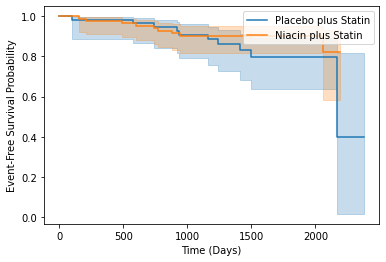

In [16]:
# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax = reporting.plot_kaplanmeier(y_train.iloc[idx_list_0], x_train['RandAssi_1.0'].iloc[idx_list_0])
h, l = ax.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Placebo plus Statin', 'Niacin plus Statin'], loc="upper right")
plt.show()

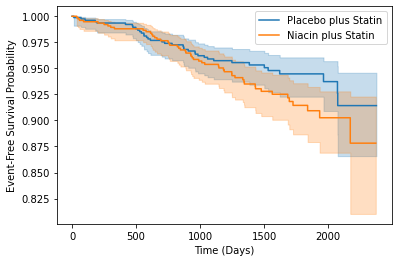

In [17]:
# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax2 = reporting.plot_kaplanmeier(y_train.iloc[idx_list_1], x_train['RandAssi_1.0'].iloc[idx_list_1])
h, l = ax2.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Placebo plus Statin', 'Niacin plus Statin'], loc="upper right")
plt.show()

In [20]:
zeta_probs_test = model.predict_latent_phi(x_te)
zeta_test =  np.argmax(zeta_probs_test, axis=1)
zeta_test

array([1, 1, 1, ..., 1, 1, 1], dtype=int64)

In [21]:
zeta_test.mean()

0.9068541300527241

In [22]:
idx_list_0te = np.where(zeta_test == 0)
idx_list_1te = np.where(zeta_test == 1)

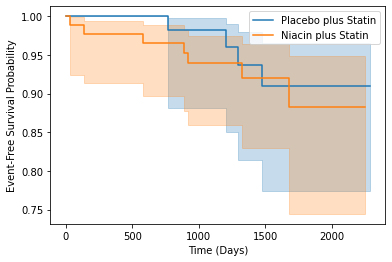

In [23]:
# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax3 = reporting.plot_kaplanmeier(y_test.iloc[idx_list_0te], x_test['RandAssi_1.0'].iloc[idx_list_0te])
h, l = ax3.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Placebo plus Statin', 'Niacin plus Statin'], loc="upper right")
plt.show()

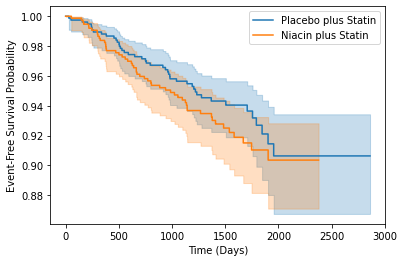

In [24]:
# Estimate the probability of event-free survival for phenotypes using the Kaplan Meier estimator.
ax4 = reporting.plot_kaplanmeier(y_test.iloc[idx_list_1te], x_test['RandAssi_1.0'].iloc[idx_list_1te])
h, l = ax4.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Placebo plus Statin', 'Niacin plus Statin'], loc="upper right")
plt.show()

In [15]:
q = [0.9, 0.8, 0.7, 0.6]
zeta_train_qt = np.quantile(zeta_probs_train[:, 0], q)

In [16]:
idx_list_qt10 = np.where(zeta_probs_train[:, 0] >= zeta_train_qt[0])
idx_list_qt20 = np.where(zeta_probs_train[:, 0] >= zeta_train_qt[1])
idx_list_qt30 = np.where(zeta_probs_train[:, 0] >= zeta_train_qt[2])
idx_list_qt40 = np.where(zeta_probs_train[:, 0] >= zeta_train_qt[3])

In [17]:
zeta_probs_test = model.predict_latent_phi(x_te)
zeta_test =  np.argmax(zeta_probs_test, axis=1)
zeta_test

array([1, 1, 1, ..., 1, 1, 1], dtype=int64)

In [18]:
zeta_test_qt = np.quantile(zeta_probs_test[:, 0], q)

In [19]:
idx_list_qt10te = np.where(zeta_probs_test[:, 0] >= zeta_test_qt[0])
idx_list_qt20te = np.where(zeta_probs_test[:, 0] >= zeta_test_qt[1])
idx_list_qt30te = np.where(zeta_probs_test[:, 0] >= zeta_test_qt[2])
idx_list_qt40te = np.where(zeta_probs_test[:, 0] >= zeta_test_qt[3])

In [20]:
# zeta 1
zeta_train_qt1 = np.quantile(zeta_probs_train[:, 1], q)
idx_list_qt10_1 = np.where(zeta_probs_train[:, 1] >= zeta_train_qt1[0])
idx_list_qt20_1 = np.where(zeta_probs_train[:, 1] >= zeta_train_qt1[1])
idx_list_qt30_1 = np.where(zeta_probs_train[:, 1] >= zeta_train_qt1[2])
idx_list_qt40_1 = np.where(zeta_probs_train[:, 1] >= zeta_train_qt1[3])

In [21]:
# zeta 1
zeta_test_qt1 = np.quantile(zeta_probs_test[:, 1], q)
idx_list_qt10te_1 = np.where(zeta_probs_test[:, 1] >= zeta_test_qt1[0])
idx_list_qt20te_1 = np.where(zeta_probs_test[:, 1] >= zeta_test_qt1[1])
idx_list_qt30te_1 = np.where(zeta_probs_test[:, 1] >= zeta_test_qt1[2])
idx_list_qt40te_1 = np.where(zeta_probs_test[:, 1] >= zeta_test_qt1[3])

TypeError: lifelines.fitters.kaplan_meier_fitter.KaplanMeierFitter.plot() got multiple values for keyword argument 'ax'

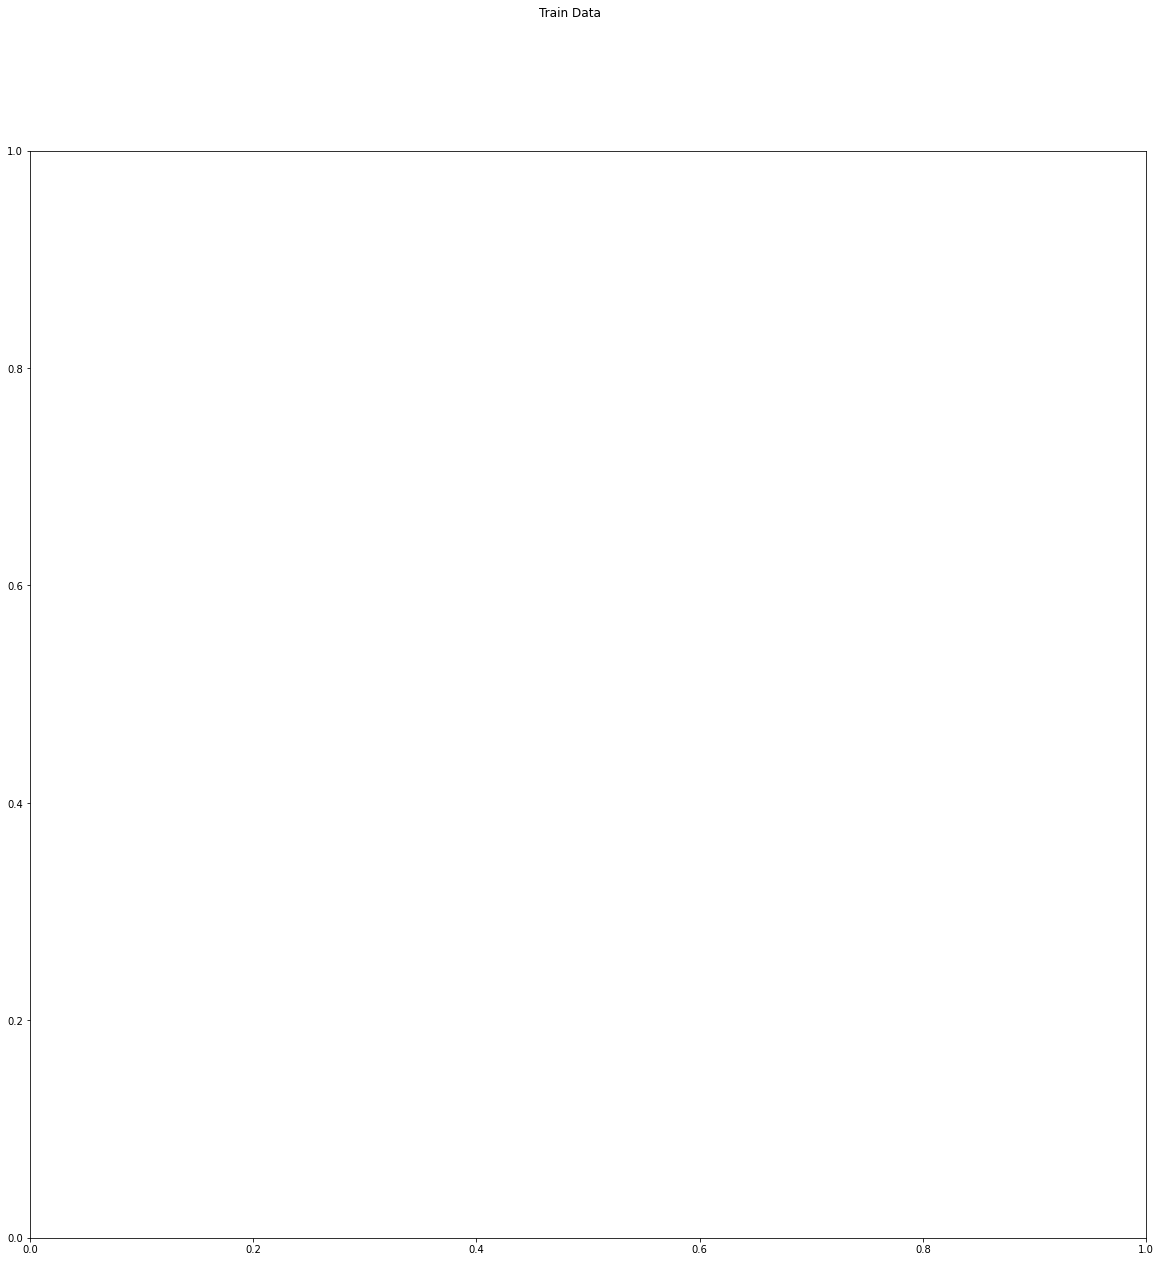

In [24]:
fig, ((ax5, ax13), (ax6, ax14), (ax7, ax15), (ax8, ax16)) = plt.subplots(4, 2, figsize= (20, 20))
fig.suptitle('Train Data')
reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt10], x_train['RandAssi_1.0'].iloc[idx_list_qt10], ax=ax5)
reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt20], x_train['RandAssi_1.0'].iloc[idx_list_qt20], ax=ax6)
reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt30], x_train['RandAssi_1.0'].iloc[idx_list_qt30], ax=ax7) 
reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt40], x_train['RandAssi_1.0'].iloc[idx_list_qt40], ax=ax8)
reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt10_1], x_train['RandAssi_1.0'].iloc[idx_list_qt10_1], ax=ax13)
reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt20_1], x_train['RandAssi_1.0'].iloc[idx_list_qt20_1], ax=ax14)
reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt30_1], x_train['RandAssi_1.0'].iloc[idx_list_qt30_1], ax=ax15)
reporting.plot_kaplanmeier(y_train.iloc[idx_list_qt40_1], x_train['RandAssi_1.0'].iloc[idx_list_qt40_1], ax=ax16) 
for ax in fig.get_axes():
    ax.label_outer()
    h, l = ax.get_legend_handles_labels()
    ax.set_xlabel('Time (Days)')
    ax.set_ylabel('Event-Free Survival Probability')
    ax.legend([h[0], h[1]], ['Placebo plus Statin', 'Niacin plus Statin'], loc="upper right")
plt.show()